# Limpieza de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = 'whitegrid')

In [9]:
df = pd.read_csv('./Datos/train.csv')
print("Dataset cargado correctamente")

Dataset cargado correctamente


In [10]:
print("Primeras filas del dataset:")
display(df.head())

print("Información general del dataset:")
display(df.info())

print("Dimensiones del dataset:")
print(df.shape)

Primeras filas del dataset:


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  str    
 3   room_type               74111 non-null  str    
 4   amenities               74111 non-null  str    
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  str    
 8   cancellation_policy     74111 non-null  str    
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  str    
 11  description             74111 non-null  str    
 12  first_review            58247 non-null  str    
 13  host_has_profile_pic    73923 non-null  str    
 14  host_identity_ve

None

Dimensiones del dataset:
(74111, 29)


In [11]:
print("Valores nulos por columna:")

null_val = df.isnull().sum()

display(
    null_val[null_val > 0 ]
    .sort_values(ascending = False)
)

Valores nulos por columna:


host_response_rate        18299
review_scores_rating      16722
first_review              15864
last_review               15827
thumbnail_url              8216
neighbourhood              6872
zipcode                     966
bathrooms                   200
host_has_profile_pic        188
host_identity_verified      188
host_since                  188
beds                        131
bedrooms                     91
dtype: int64

In [12]:
cols_to_drop = [
    'id',
    'thumbnail_url',
    'description',
    'name',
    'zipcode',
    'first_review',
    'last_review',
    'host_since',
    'amenities'
]

df = df.drop(columns = cols_to_drop)
print("Columnas elimindas correctamente")

Columnas elimindas correctamente


In [13]:
df['host_response_rate'] = (
    df['host_response_rate']
    .str.replace('%', '', regex = False)
)

df['host_response_rate'] = pd.to_numeric(
    df['host_response_rate'],
    errors = 'coerce'
)

print("Columna convertida correctamente")

Columna convertida correctamente


In [15]:
numeric_col = df.select_dtypes(
    include = ['int64', 'float64']
).columns

for col in numeric_col:
    df[col] = df[col].fillna(
        df[col].median()
    )

print("Valores numéricos nulos imputados")

Valores numéricos nulos imputados


In [16]:
categorical_col = df.select_dtypes(
    include = ['object', 'bool']
).columns

for column in categorical_col:
    df[col] = df[col].fillna(
        df[column].mode()[0]
    )

print("Valores categóricos nulos imputados")

Valores categóricos nulos imputados


C:\Users\diego\AppData\Local\Temp\ipykernel_19200\3024114382.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = df.select_dtypes(


In [17]:
print("Cantidad de duplicados:")
print(df.duplicated().sum())

df = df.drop_duplicates()
print("Duplicados eliminados")

Cantidad de duplicados:
0
Duplicados eliminados


In [19]:
Q1 = df['log_price'].quantile(0.25)
Q3 = df['log_price'].quantile(0.75)

IQR = Q3 -Q1

lower_limit = Q1 - 1.5 * IQR 
upper_limit = Q1 + 1.5 * IQR

df = df[
    (df['log_price'] >= lower_limit) &
    (df['log_price'] <= upper_limit)
]

print("Outliers eliminados correctamente")

Outliers eliminados correctamente


In [20]:
print("Información general limpia:")
df.info()

Información general limpia:
<class 'pandas.DataFrame'>
Index: 65930 entries, 0 to 74110
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   log_price               65930 non-null  float64
 1   property_type           65930 non-null  str    
 2   room_type               65930 non-null  str    
 3   accommodates            65930 non-null  int64  
 4   bathrooms               65930 non-null  float64
 5   bed_type                65930 non-null  str    
 6   cancellation_policy     65930 non-null  str    
 7   cleaning_fee            65930 non-null  bool   
 8   city                    65930 non-null  str    
 9   host_has_profile_pic    65753 non-null  str    
 10  host_identity_verified  65753 non-null  str    
 11  host_response_rate      65930 non-null  float64
 12  instant_bookable        65930 non-null  str    
 13  latitude                65930 non-null  float64
 14  longitude               65

In [22]:
df.to_csv(
    './Datos/dataset_limpio.csv',
    index = False
)

print("Dataset exportado correctamente")

Dataset exportado correctamente


# Modelo

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error
)
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)
import statsmodels.api as sm

sns.set_theme(style = 'whitegrid')

In [26]:
df = pd.read_csv('./Datos/dataset_limpio.csv')
print("Dataset limpio cargado correctamente")

Dataset limpio cargado correctamente


In [31]:
selected_col = [
    'log_price',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'cleaning_fee',
    'number_of_reviews',
    'host_response_rate',
    'latitude',
    'longitude',
    'property_type',
    'room_type',
    'bed_type',
    'cancellation_policy',
    'city',
    'instant_bookable'
]

model_df = df[selected_col]
print("Variables seleccionadas correctamente")

Variables seleccionadas correctamente


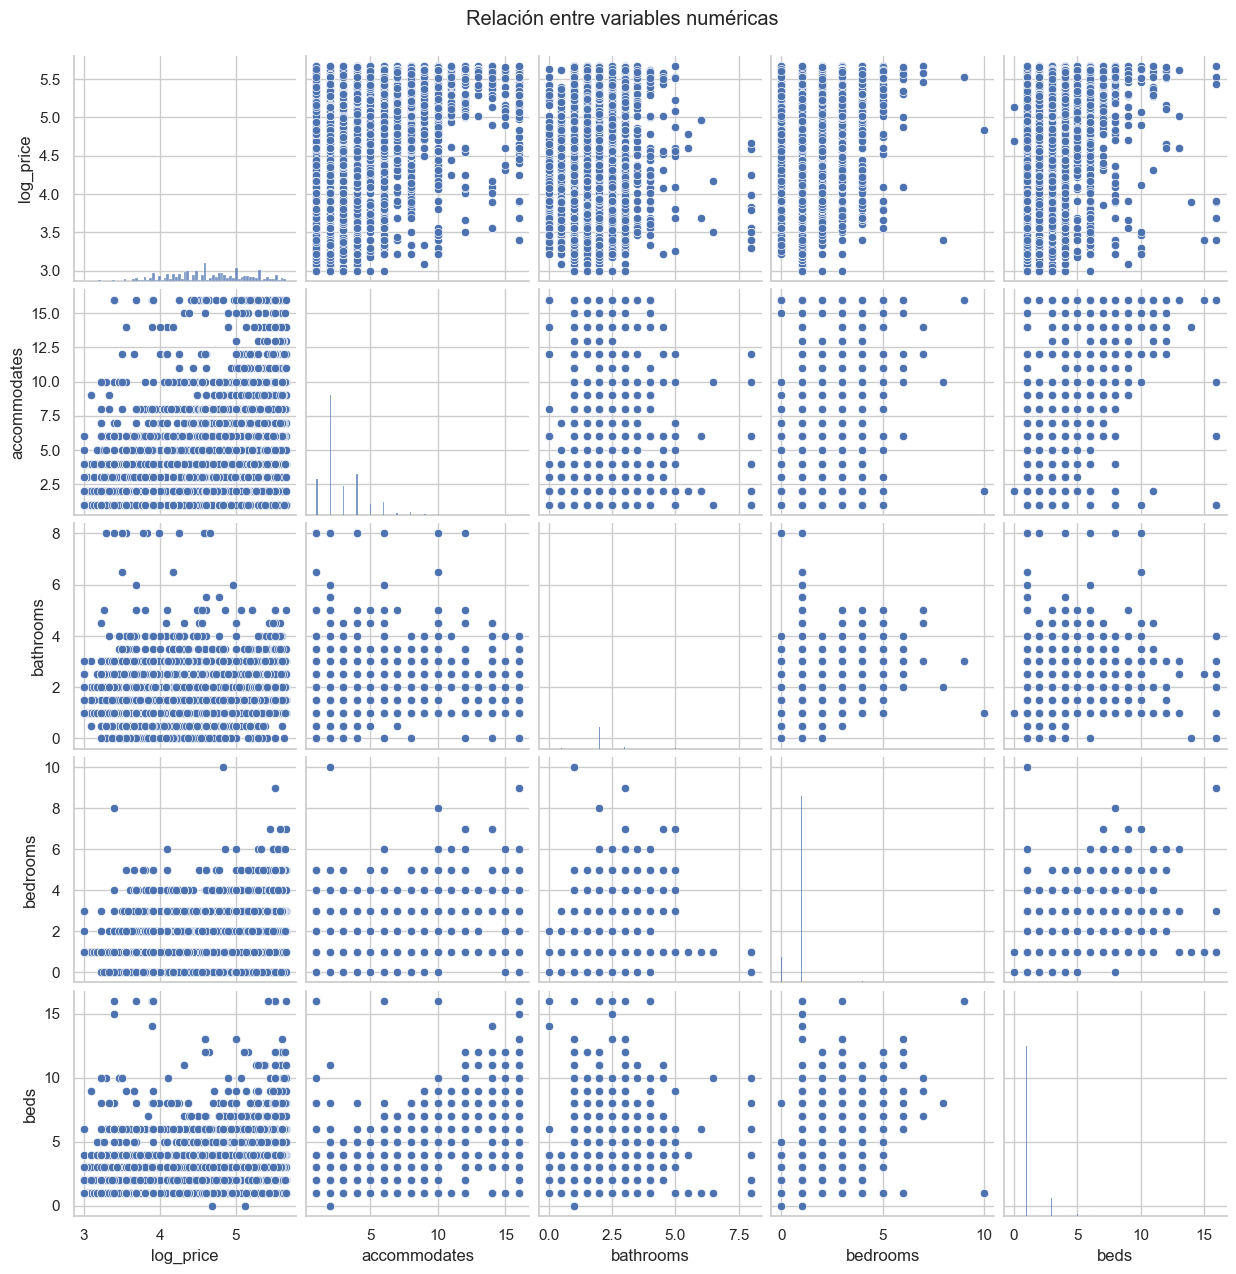

In [32]:
sns.pairplot(
    model_df[
        [
            'log_price',
            'accommodates',
            'bathrooms',
            'bedrooms',
            'beds'
        ]
    ]
)

plt.suptitle(
    'Relación entre variables numéricas',
    y = 1.02
)

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

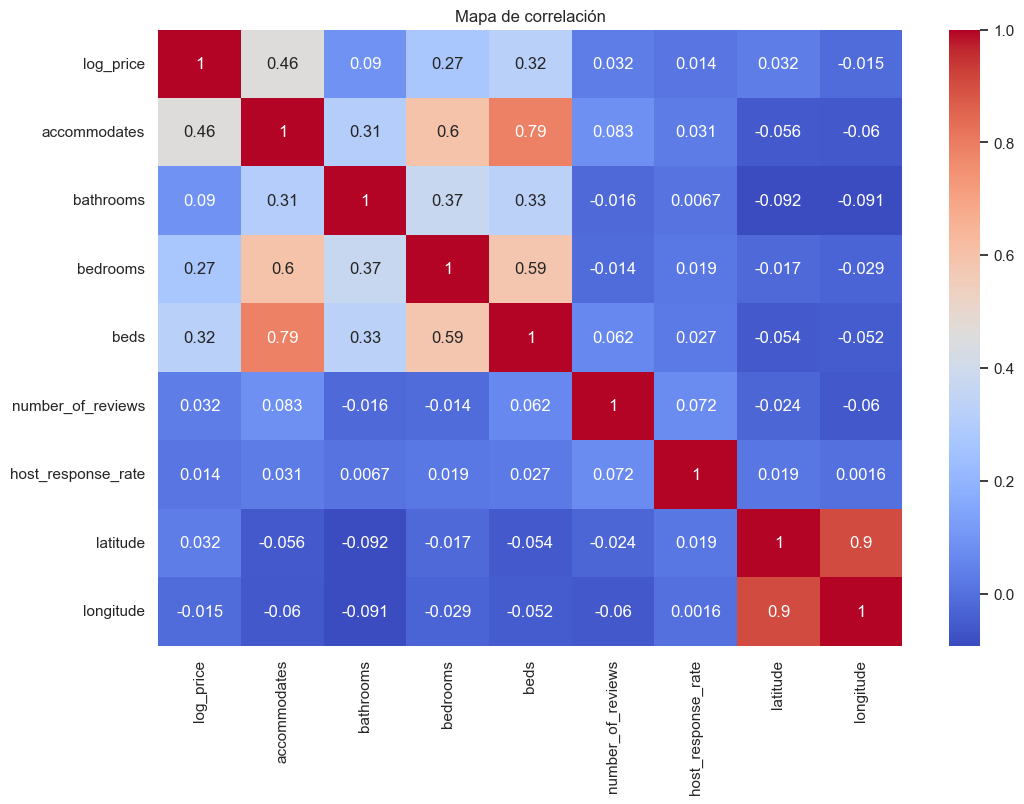

In [34]:
plt.figure(figsize = (12,8))
sns.heatmap(
    model_df.select_dtypes(
        include = ['int64', 'float64']
    ).corr(),
    annot = True,
    cmap = 'coolwarm',
)

plt.title('Mapa de correlación')
plt.show

In [36]:
y = model_df['log_price']
x = model_df.drop(columns = ['log_price'])

print("Variable dependiente e independiente definidas")

Variable dependiente e independiente definidas


In [37]:
x = pd.get_dummies(
    x,
    drop_first = True,
    dtype = int
)

print("Variables categóricas codificadas correctamente")

Variables categóricas codificadas correctamente


In [38]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)

print("Datos divididos correctamente")

Datos divididos correctamente


In [40]:
model = LinearRegression()
model.fit(x_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [41]:
y_pred = model.predict(x_test)

print("Predicciones realizadas")

Predicciones realizadas


In [42]:
r2 = r2_score(
    y_test, 
    y_pred
)

print("R2 del modelo:")
print(r2)

R2 del modelo:
0.5241053915443732


In [43]:
n = x_test.shape[0]
p = x_test.shape[1]
adjusted_r2 = 1 - (
    (1 -r2) * (n - 1) / (n - p -1)
)

print("R2 ajustado del modelo:")
print(adjusted_r2)

R2 ajustado del modelo:
0.5219662949499132


In [44]:
mse = mean_squared_error(
    y_test,
    y_pred
)

print("Error cuadrático medio:")
print(mse)

Error cuadrático medio:
0.14077653626959918


In [46]:
x_vif = x.astype(float)
x_vif = sm.add_constant(x_vif)
vif_data = pd.DataFrame()
vif_data['Variable'] = x_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(
        x_vif.values,
        i
    )
    for i in range(x_vif.shape[1])
]

print("Valores VIF:")

display(
    vif_data.sort_values(
        by = 'VIF',
        ascending  = False
    )
)

Valores VIF:


,Variable,VIF
0,const,961188.424396
56,city_LA,67438.202242
9,longitude,61117.295026
58,city_SF,25151.502925
8,latitude,2036.643729
54,city_Chicago,1789.136287
55,city_DC,495.895057
57,city_NYC,440.283486
49,bed_type_Real Bed,4.376108
1,accommodates,3.518518


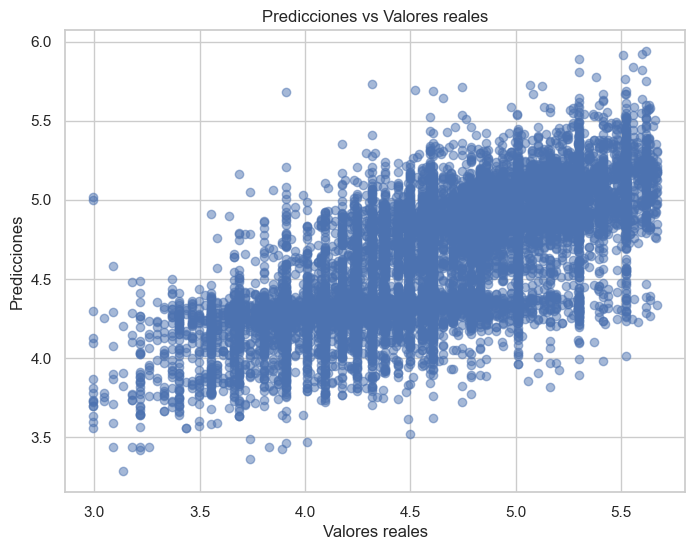

In [47]:
plt.figure(figsize = (8, 6))
plt.scatter(
    y_test,
    y_pred,
    alpha = 0.5
)

plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores reales')
plt.show()

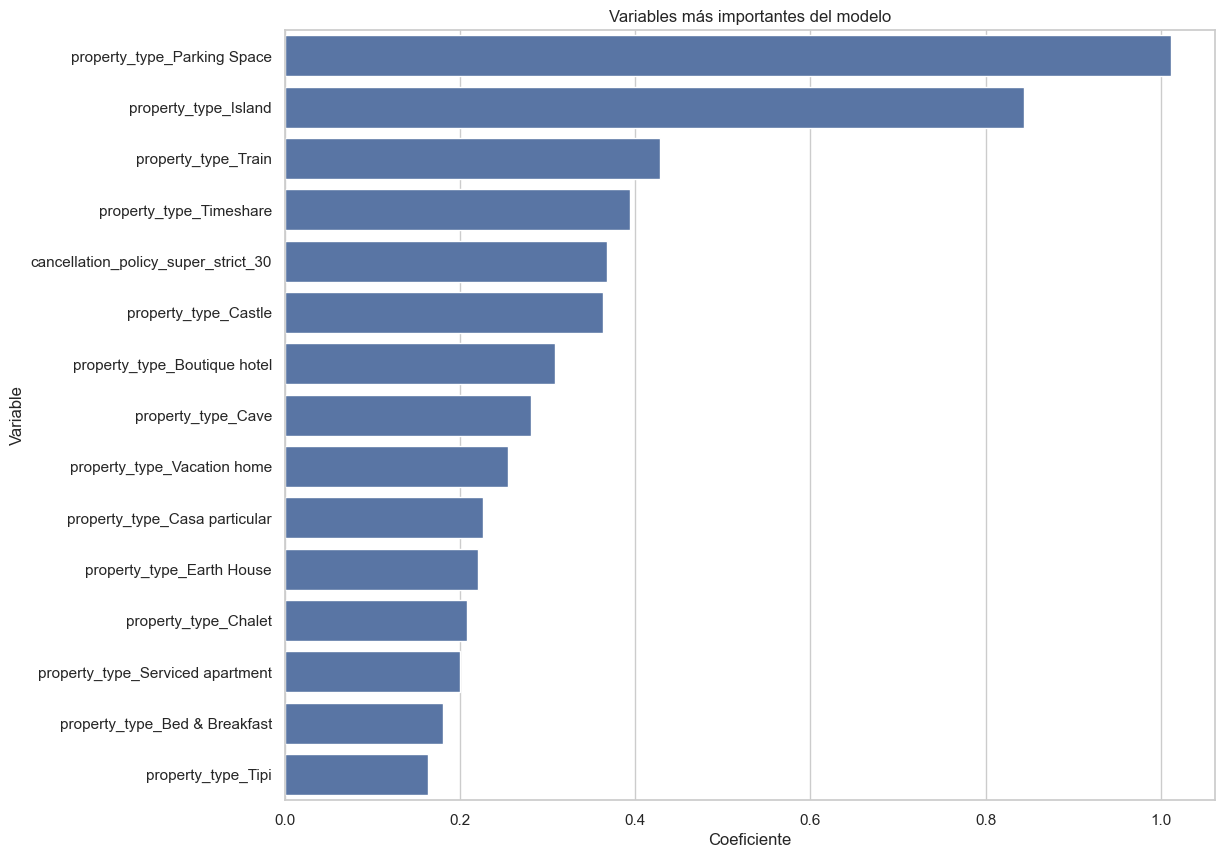

In [48]:
coefficients = pd.DataFrame({
    'Variable': x.columns,
    'Coeficiente': model.coef_
})

coefficients = coefficients.sort_values(
    by = 'Coeficiente',
    ascending = False
)

plt.figure(figsize = (12, 10))

sns.barplot(
    data = coefficients.head(15),
    x = 'Coeficiente',
    y = 'Variable'
)

plt.title(
    "Variables más importantes del modelo"
)

plt.show()